# RUL Calculation and Leakage-Safe Feature Engineering

## Objective

This notebook prepares the NASA C-MAPSS FD001 training data for predictive modeling.

The main objectives are:

1. Calculate Remaining Useful Life (`RUL`) for every engine cycle.
2. Distinguish between the prediction target and model features.
3. Create historical sensor features using only information available up to the current cycle.
4. Prevent data leakage from future engine observations.
5. Validate the engineered features before moving to model development.

The features created in this notebook are demonstrated using sensor `s2`. The same leakage-safe methods can later be applied to other selected sensors inside the modeling pipeline.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_cmapss_data
from src.rul_builder import add_train_rul
from src.preprocessing import add_sensor_history_features

## Load the FD001 Training Data

The FD001 training dataset contains complete run-to-failure histories
for multiple engines.

Each row represents one engine at one operating cycle and includes:

- Engine ID
- Current operating cycle
- Three operational settings
- Twenty-one sensor measurements

The dataset is loaded through the reusable `load_cmapss_data`
function from `src/data_loader.py`, ensuring that the same loading
logic is shared across the project.

In [2]:
data_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "train_FD001.txt"
)

df = load_cmapss_data(data_path)

df.head()

,id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
print("Dataset shape:", df.shape)
print("Number of engines:", df["id"].nunique())
print("Missing values:", df.isna().sum().sum())

df.dtypes

Dataset shape: (20631, 26)
Number of engines: 100
Missing values: 0


id             int64
cycle          int64
setting_1    float64
setting_2    float64
setting_3    float64
s1           float64
s2           float64
s3           float64
s4           float64
s5           float64
s6           float64
s7           float64
s8           float64
s9           float64
s10          float64
s11          float64
s12          float64
s13          float64
s14          float64
s15          float64
s16          float64
s17            int64
s18            int64
s19          float64
s20          float64
s21          float64
dtype: object

## Sort the Data by Engine and Cycle

Time-dependent features such as differences, rolling averages, exponential moving averages, and expanding statistics require the observations to be in the correct chronological order.

Therefore, the dataset is sorted first by engine ID and then by operating cycle.

In [4]:
df = (
    df.sort_values(["id", "cycle"])
      .reset_index(drop=True)
)

df[["id", "cycle"]].head(10)

,id,cycle
0,1,1
1,1,2
2,1,3
3,1,4
4,1,5
5,1,6
6,1,7
7,1,8
8,1,9
9,1,10


# Remaining Useful Life Target

Remaining Useful Life (`RUL`) represents the number of operating cycles
remaining before an engine reaches the end of its recorded lifetime.

For each engine:

`RUL = final observed cycle - current cycle`

The target is constructed using the reusable `add_train_rul` function
from `src/rul_builder.py`.

The final observed cycle is used internally only to construct the
supervised-learning target. It is not retained in the DataFrame and
must not be used as a model feature because it is unavailable during
real-world operation.

In [5]:
df = add_train_rul(df)

df[["id", "cycle", "RUL"]].head(10)

,id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [6]:
rul_validation = (
    df.groupby("id")
      .agg(
          first_cycle=("cycle", "min"),
          final_cycle=("cycle", "max"),
          maximum_rul=("RUL", "max"),
          final_rul=("RUL", "min")
      )
)

rul_validation.head()

,first_cycle,final_cycle,maximum_rul,final_rul
id,,,,
1,1,192,191,0
2,1,287,286,0
3,1,179,178,0
4,1,189,188,0
5,1,269,268,0


In [7]:
assert (df["RUL"] >= 0).all(), "RUL must not contain negative values."
assert (df.groupby("id").tail(1)["RUL"] == 0).all(), (
    "The final cycle of every engine must have RUL equal to zero."
)

print("RUL validation passed.")

RUL validation passed.


## Target Construction and Data Leakage

The final recorded cycle of each training engine is required to
construct the historical RUL label.

However, this information is unavailable while an engine is operating
in real time. For example, at cycle 50, the system does not know whether
the engine will fail at cycle 180, 220, or another future cycle.

Therefore:

- `RUL` is used only as the prediction target.
- The final engine cycle is calculated internally inside
  `add_train_rul`.
- The final cycle is not retained as a DataFrame column.
- Neither the target nor future-lifetime information is included in
  model input features.
- Features based on the complete future history of an engine are not
  created.

# Leakage-Safe Historical Feature Engineering

In a real operational environment, the prediction system has access only to:

- The current sensor measurements
- Measurements recorded during previous cycles
- The current operating cycle

It does not have access to future sensor values.

For this reason, every historical feature below is calculated separately for each engine and uses only data available up to the current cycle.

The historical features are generated through the reusable
`add_sensor_history_features` function from `src/preprocessing.py`.

The function supports multiple sensors, configurable rolling windows,
and configurable EMA spans. In this notebook, `s2` is used as a
demonstration sensor before applying the same process to the final
sensor set selected during sensor analysis.

In [8]:
feature_sensors = ["s2"]

df = add_sensor_history_features(
    df,
    sensors=feature_sensors,
    rolling_window=5,
    ema_span=5,
).reset_index(drop=True)

In [9]:
feature_columns = [
    "id",
    "cycle",
    "s2",
    "s2_diff_1",
    "s2_rolling_mean_5",
    "s2_ema_5",
    "s2_expanding_mean"
]

df[feature_columns].head(10)

,id,cycle,s2,s2_diff_1,s2_rolling_mean_5,s2_ema_5,s2_expanding_mean
0,1,1,641.82,0.00,641.820000,641.820000,641.820000
1,1,2,642.15,0.33,641.985000,641.930000,641.985000
2,1,3,642.35,0.20,642.106667,642.070000,642.106667
3,1,4,642.35,0.00,642.167500,642.163333,642.167500
4,1,5,642.37,0.02,642.208000,642.232222,642.208000
5,1,6,642.10,-0.27,642.264000,642.188148,642.190000
6,1,7,642.48,0.38,642.330000,642.285432,642.231429
7,1,8,642.56,0.08,642.372000,642.376955,642.272500
8,1,9,642.12,-0.44,642.326000,642.291303,642.255556
9,1,10,641.71,-0.41,642.194000,642.097535,642.201000


## 1. Raw Sensor Value

The original `s2` measurement is preserved.

Raw sensor values are important because they retain immediate changes, sudden spikes, and short-term variations that may be hidden by smoothing methods.

## 2. One-Cycle Sensor Difference

The one-cycle difference measures how much the sensor value has changed compared with the previous cycle of the same engine.

This feature uses only the current and previous observations and therefore does not introduce future-data leakage.

## 3. Five-Cycle Rolling Mean

A rolling mean reduces short-term fluctuations and provides a view of the recent local sensor trend.

At each cycle, the five-cycle rolling mean uses the current observation and up to four previous observations from the same engine.

The raw sensor value remains available alongside the rolling feature so that sudden changes are not completely hidden.

## 4. Exponential Moving Average

The Exponential Moving Average (`EMA`) represents the recent sensor trend while assigning greater weight to newer observations.

Compared with a simple rolling mean, EMA reacts more quickly to recent changes and may reduce some of the delay introduced by equal-weight moving averages.

The calculation is performed independently for each engine and uses only the current and previous cycles.

## 5. Expanding Mean

The expanding mean provides a cumulative historical baseline for each engine.

At a given cycle, it uses all observations recorded from the first cycle up to and including the current cycle.

Unlike a full-engine average, the expanding mean does not use future observations.

## Same-Cycle Prediction Assumption

The historical features in this notebook include the current cycle measurement.

This is appropriate because the intended task is to estimate RUL after receiving the sensor readings of the current cycle.

If the objective were instead to predict the next cycle before its measurements became available, the historical features would need to be shifted by one cycle.

In [10]:
engine_1_features = df.loc[
    df["id"] == 1,
    [
        "id",
        "cycle",
        "s2",
        "s2_diff_1",
        "s2_rolling_mean_5",
        "s2_ema_5",
        "s2_expanding_mean",
        "RUL"
    ]
]

engine_1_features.head(15)

,id,cycle,s2,s2_diff_1,s2_rolling_mean_5,s2_ema_5,s2_expanding_mean,RUL
0,1,1,641.82,0.00,641.820000,641.820000,641.820000,191
1,1,2,642.15,0.33,641.985000,641.930000,641.985000,190
2,1,3,642.35,0.20,642.106667,642.070000,642.106667,189
3,1,4,642.35,0.00,642.167500,642.163333,642.167500,188
4,1,5,642.37,0.02,642.208000,642.232222,642.208000,187
5,1,6,642.10,-0.27,642.264000,642.188148,642.190000,186
6,1,7,642.48,0.38,642.330000,642.285432,642.231429,185
7,1,8,642.56,0.08,642.372000,642.376955,642.272500,184
8,1,9,642.12,-0.44,642.326000,642.291303,642.255556,183
9,1,10,641.71,-0.41,642.194000,642.097535,642.201000,182


## Feature Validation

The following checks confirm that:

1. The first-cycle difference is zero for every engine.
2. The historical features contain no missing values.
3. Feature engineering preserves the original number of rows.
4. The future-only `max_cycle` column is absent from the DataFrame.
5. The target column is not part of the demonstration feature list.

In [11]:
engineered_features = [
    f"{sensor}_{suffix}"
    for sensor in feature_sensors
    for suffix in [
        "diff_1",
        "rolling_mean_5",
        "ema_5",
        "expanding_mean",
    ]
]

first_cycles = df.groupby("id").head(1)

for sensor in feature_sensors:
    assert (first_cycles[f"{sensor}_diff_1"] == 0).all(), (
        f"The first {sensor} difference must be zero for every engine."
    )

assert df[engineered_features].isna().sum().sum() == 0, (
    "Engineered features must not contain missing values."
)

assert len(df) == 20631, (
    "Feature engineering must not change the number of dataset rows."
)

expected_order = (
    df[["id", "cycle"]]
    .sort_values(["id", "cycle"])
    .reset_index(drop=True)
)

actual_order = (
    df[["id", "cycle"]]
    .reset_index(drop=True)
)

assert actual_order.equals(expected_order), (
    "The dataset must remain sorted by engine id and cycle."
)

assert "max_cycle" not in df.columns, (
    "Future lifetime information must not remain in the DataFrame."
)

assert "RUL" not in engineered_features, (
    "The target column must not be included in engineered features."
)

print("Leakage-safe feature validation passed.")

Leakage-safe feature validation passed.


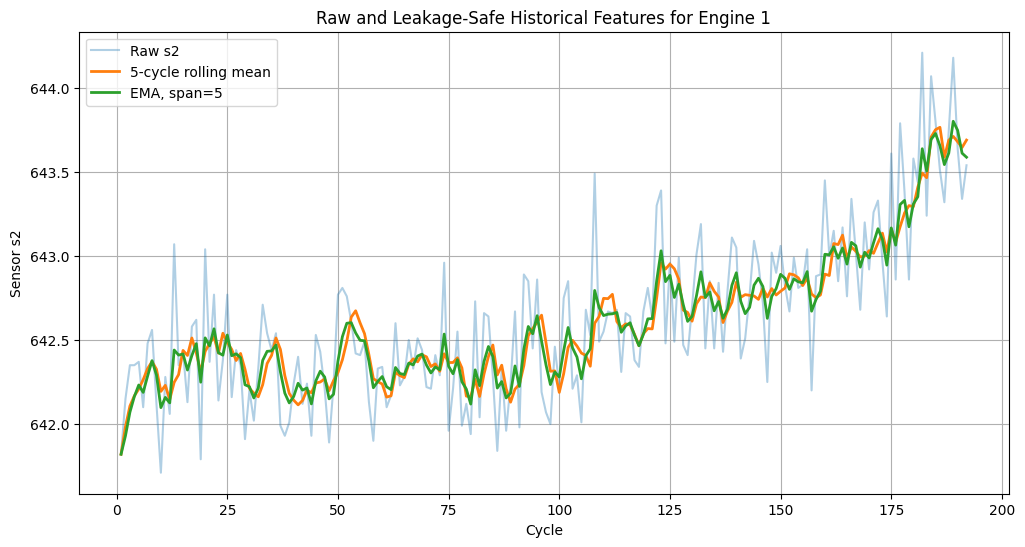

In [12]:
engine_id = 1

engine_df = df[df["id"] == engine_id]

plt.figure(figsize=(12, 6))

plt.plot(
    engine_df["cycle"],
    engine_df["s2"],
    alpha=0.35,
    label="Raw s2"
)

plt.plot(
    engine_df["cycle"],
    engine_df["s2_rolling_mean_5"],
    linewidth=2,
    label="5-cycle rolling mean"
)

plt.plot(
    engine_df["cycle"],
    engine_df["s2_ema_5"],
    linewidth=2,
    label="EMA, span=5"
)

plt.title("Raw and Leakage-Safe Historical Features for Engine 1")
plt.xlabel("Cycle")
plt.ylabel("Sensor s2")
plt.legend()
plt.grid(True)
plt.show()

### Insight

The raw `s2` signal contains short-term fluctuations and preserves immediate changes in sensor behavior.

The five-cycle rolling mean produces a smoother local trend but may react more slowly to sudden changes because all observations inside the window receive equal weight.

The EMA also smooths the signal but gives greater importance to recent observations, allowing it to respond more quickly to new changes.

For future modeling, the raw signal and selected historical features can be evaluated together. Their actual usefulness must be determined through validation performance rather than assumed from visualization alone.

# Modeling Feature Policy

The following existing columns are excluded from model inputs:

- `id`: an engine identifier, not a degradation measurement
- `RUL`: the supervised-learning target

The following future-derived columns must not be created as model
features:

- `max_cycle`: the unknown final lifetime of the engine
- `cycle_progress` based on the actual final cycle

The current cycle is operationally available and may be evaluated as a
model feature.

For this demonstration, the leakage-safe candidate features are:

- `cycle`
- Raw `s2`
- `s2_diff_1`
- `s2_rolling_mean_5`
- `s2_ema_5`
- `s2_expanding_mean`

The final modeling pipeline will apply appropriate historical
transformations to the sensors selected during sensor analysis.

In [13]:
target_column = "RUL"

excluded_from_features = [
    "id",
    "RUL"
]

forbidden_future_columns = [
    "max_cycle",
    "cycle_progress"
]

demonstration_features = [
    "cycle",
    "s2",
    "s2_diff_1",
    "s2_rolling_mean_5",
    "s2_ema_5",
    "s2_expanding_mean"
]

assert target_column not in demonstration_features

assert not any(
    column in demonstration_features
    for column in forbidden_future_columns
)

print("Target:", target_column)
print("Excluded existing columns:", excluded_from_features)
print("Forbidden future-derived columns:", forbidden_future_columns)
print("Demonstration features:", demonstration_features)

Target: RUL
Excluded existing columns: ['id', 'RUL']
Forbidden future-derived columns: ['max_cycle', 'cycle_progress']
Demonstration features: ['cycle', 's2', 's2_diff_1', 's2_rolling_mean_5', 's2_ema_5', 's2_expanding_mean']


# Final Summary

In this notebook:

1. The FD001 training data was loaded using the shared project data
   loader and sorted by engine and operating cycle.
2. Remaining Useful Life (`RUL`) was created as the supervised-learning target.
3. The final engine cycle was used internally only for target construction
and was not retained in the modeling dataset.
4. Full-engine statistics and actual-lifetime progress features were avoided because they would expose future information.
5. Leakage-safe historical features were created using only current and previous observations:
   - One-cycle difference
   - Five-cycle rolling mean
   - Exponential moving average
   - Expanding mean
6. Raw sensor values were preserved alongside smoothed features to retain immediate changes and sudden fluctuations.
7. Automated validation checks confirmed that feature engineering did not introduce missing values or change the number of observations.

The demonstrated feature-engineering logic has now been transferred
into a reusable preprocessing function and can later be generalized
to the sensors selected during sensor analysis.